In [1]:
import pandas as pd

In [2]:
train_sample = pd.read_csv("../data/train.csv", nrows=10000)

In [3]:
train_sample.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN


In [4]:
train_sample.shape

(10000, 6)

In [5]:
train_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   date         10000 non-null  object 
 2   store_nbr    10000 non-null  int64  
 3   item_nbr     10000 non-null  int64  
 4   unit_sales   10000 non-null  float64
 5   onpromotion  0 non-null      float64
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [6]:
train_sample.isnull().sum()

id                 0
date               0
store_nbr          0
item_nbr           0
unit_sales         0
onpromotion    10000
dtype: int64

In [7]:
train_sample["date"].min(), train_sample["date"].max()

('2013-01-01', '2013-01-02')

In [8]:
train_sample["store_nbr"].nunique(), train_sample["item_nbr"].nunique()

(10, 1469)

In [9]:
train_sample["date"] = pd.to_datetime(train_sample["date"])

In [10]:
train_sample["unit_sales"].describe()

count    10000.000000
mean        11.498949
std         17.222499
min          0.252000
25%          3.000000
50%          6.000000
75%         13.000000
max        483.000000
Name: unit_sales, dtype: float64

In [11]:
train_sample["unit_sales"].sum(), train_sample["unit_sales"].mean()

(np.float64(114989.486), np.float64(11.4989486))

In [12]:
target_store = 25
target_item = 103665

chunks = []

for chunk in pd.read_csv(
    "../data/train.csv",
    chunksize=500000
):
    filtered = chunk[
        (chunk["store_nbr"] == target_store) &
        (chunk["item_nbr"] == target_item)
    ]
    
    if not filtered.empty:
        chunks.append(filtered)

product_sales = pd.concat(chunks, ignore_index=True)

product_sales["date"] = pd.to_datetime(product_sales["date"])

product_sales.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_27520\1006769183.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,19811,2013-01-02,25,103665,5.0,NaN
2,100696,2013-01-04,25,103665,5.0,NaN
3,141831,2013-01-05,25,103665,5.0,NaN
4,183815,2013-01-06,25,103665,7.0,NaN


In [13]:
product_sales.shape

(1142, 6)

In [14]:
product_sales["date"].min(), product_sales["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [15]:
product_sales.tail()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
1137,125019493,2017-08-11,25,103665,6.0,False
1138,125125144,2017-08-12,25,103665,10.0,False
1139,125230204,2017-08-13,25,103665,2.0,False
1140,125336140,2017-08-14,25,103665,2.0,False
1141,125438641,2017-08-15,25,103665,1.0,False


In [16]:
product_sales = product_sales.sort_values("date").reset_index(drop=True)

product_sales[["date", "unit_sales"]].head(15)

,date,unit_sales
0,2013-01-01,7.0
1,2013-01-02,5.0
2,2013-01-04,5.0
3,2013-01-05,5.0
4,2013-01-06,7.0
5,2013-01-07,2.0
6,2013-01-11,4.0
7,2013-01-12,11.0
8,2013-01-14,1.0
9,2013-01-15,1.0


In [17]:
date_range = pd.date_range(
    start=product_sales["date"].min(),
    end=product_sales["date"].max(),
    freq="D"
)

len(date_range), product_sales["date"].nunique()

(1688, 1142)

In [18]:
missing_dates = date_range.difference(product_sales["date"])

len(missing_dates), missing_dates[:10]

(546,
 DatetimeIndex(['2013-01-03', '2013-01-08', '2013-01-09', '2013-01-10',
                '2013-01-13', '2013-01-17', '2013-01-23', '2013-01-24',
                '2013-01-28', '2013-01-29'],
               dtype='datetime64[ns]', freq=None))

In [19]:
product_sales["date_diff"] = product_sales["date"].diff().dt.days

product_sales["date_diff"].value_counts().sort_index().head(15)

date_diff
1.0     845
2.0     190
3.0      60
4.0      28
5.0       8
6.0       3
7.0       4
8.0       2
68.0      1
Name: count, dtype: int64

In [20]:
product_sales["date_diff"].describe()

count    1141.000000
mean        1.478528
std         2.167285
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        68.000000
Name: date_diff, dtype: float64

In [21]:
product_sales.loc[
    product_sales["date_diff"] > 7,
    ["date", "unit_sales", "date_diff"]
].head(20)

,date,unit_sales,date_diff
655,2015-05-24,4.0,8.0
680,2015-07-21,1.0,8.0
918,2016-10-27,1.0,68.0


In [22]:
product_sales.loc[
    (product_sales["date"] >= "2016-10-20") &
    (product_sales["date"] <= "2016-11-05"),
    ["date", "unit_sales"]
]

,date,unit_sales
918,2016-10-27,1.0
919,2016-10-28,4.0
920,2016-10-29,1.0
921,2016-10-30,3.0
922,2016-11-01,4.0
923,2016-11-02,5.0
924,2016-11-03,6.0
925,2016-11-04,11.0


In [23]:
product_sales.loc[
    (product_sales["date"] >= "2015-05-15") &
    (product_sales["date"] <= "2015-07-25"),
    ["date", "unit_sales"]
]

,date,unit_sales
654,2015-05-16,5.0
655,2015-05-24,4.0
656,2015-05-25,2.0
657,2015-05-28,4.0
658,2015-05-29,2.0
659,2015-06-03,1.0
660,2015-06-04,1.0
661,2015-06-05,2.0
662,2015-06-06,1.0
663,2015-06-07,1.0


In [26]:
product_sales.loc[
    (product_sales["date"] >= "2016-08-15") &
    (product_sales["date"] <= "2016-11-05"),
    ["date", "unit_sales"]
]

,date,unit_sales
913,2016-08-15,2.0
914,2016-08-17,1.0
915,2016-08-18,1.0
916,2016-08-19,7.0
917,2016-08-20,1.0
918,2016-10-27,1.0
919,2016-10-28,4.0
920,2016-10-29,1.0
921,2016-10-30,3.0
922,2016-11-01,4.0


In [27]:
product_sales.drop(columns="date_diff", inplace=True)

In [28]:
daily_sales = (
    product_sales[["date", "unit_sales"]]
    .set_index("date")
    .asfreq("D", fill_value=0)
)

In [29]:
daily_sales.head(15)

,unit_sales
date,
2013-01-01,7.0
2013-01-02,5.0
2013-01-03,0.0
2013-01-04,5.0
2013-01-05,5.0
2013-01-06,7.0
2013-01-07,2.0
2013-01-08,0.0
2013-01-09,0.0


In [30]:
daily_sales.loc["2016-08-20":"2016-09-05"]

,unit_sales
date,
2016-08-20,1.0
2016-08-21,0.0
2016-08-22,0.0
2016-08-23,0.0
2016-08-24,0.0
2016-08-25,0.0
2016-08-26,0.0
2016-08-27,0.0
2016-08-28,0.0


In [31]:
daily_sales.shape

(1688, 1)

In [32]:
daily_sales.isnull().sum()

unit_sales    0
dtype: int64

In [33]:
import matplotlib.pyplot as plt

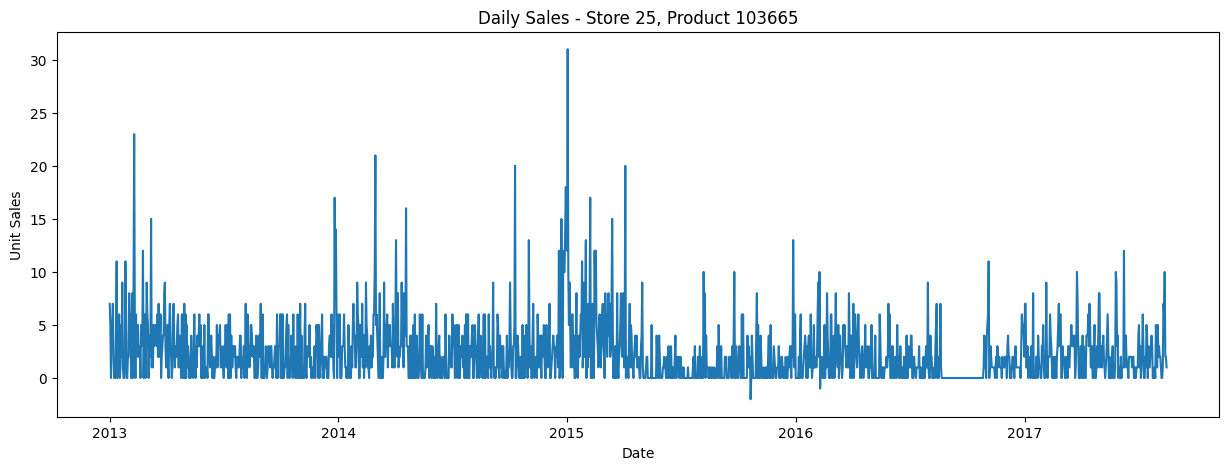

In [34]:
plt.figure(figsize=(15, 5))
plt.plot(daily_sales.index, daily_sales["unit_sales"])
plt.title("Daily Sales - Store 25, Product 103665")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

In [35]:
daily_sales["rolling_7"] = (
    daily_sales["unit_sales"]
    .rolling(window=7)
    .mean()
)

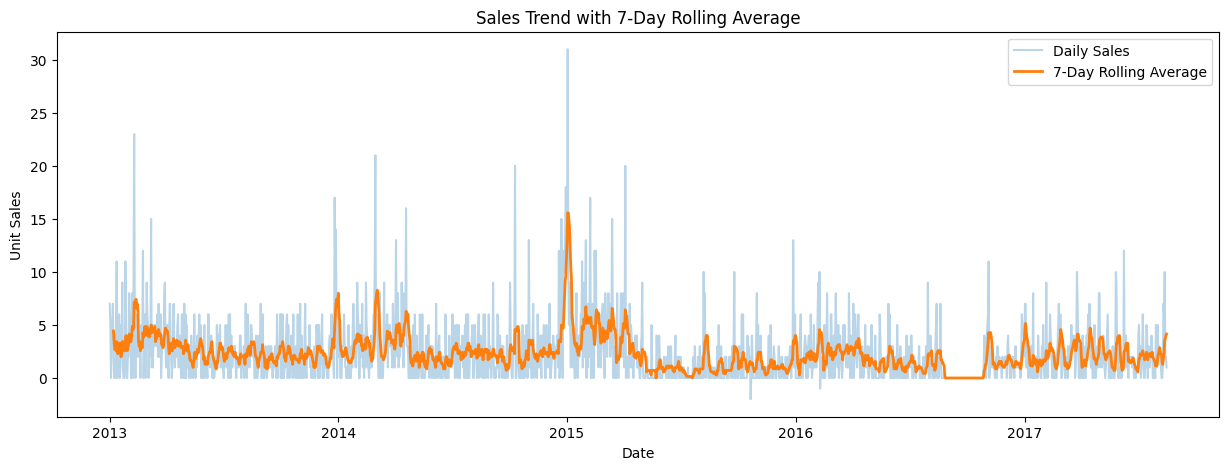

In [36]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_sales.index,
    daily_sales["unit_sales"],
    alpha=0.3,
    label="Daily Sales"
)

plt.plot(
    daily_sales.index,
    daily_sales["rolling_7"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("Sales Trend with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

In [37]:
daily_sales["day_of_week"] = daily_sales.index.day_name()

weekly_pattern = (
    daily_sales
    .groupby("day_of_week")["unit_sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekly_pattern

day_of_week
Monday       1.692946
Tuesday      1.698347
Wednesday    2.004149
Thursday     1.900415
Friday       3.240664
Saturday     3.684647
Sunday       2.037344
Name: unit_sales, dtype: float64

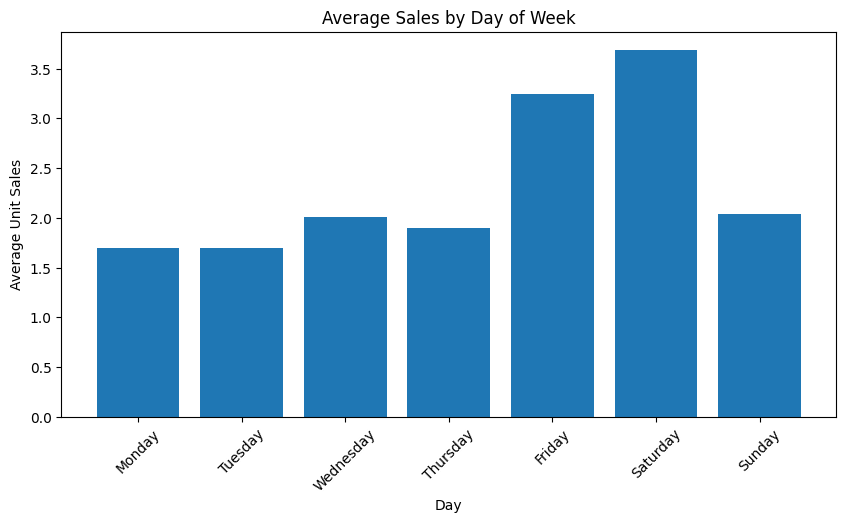

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(weekly_pattern.index, weekly_pattern.values)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Unit Sales")

plt.xticks(rotation=45)
plt.show()

In [39]:
daily_sales["day_of_week_num"] = daily_sales.index.dayofweek
daily_sales["day_of_month"] = daily_sales.index.day
daily_sales["month"] = daily_sales.index.month
daily_sales["year"] = daily_sales.index.year

In [40]:
daily_sales["lag_1"] = daily_sales["unit_sales"].shift(1)
daily_sales["lag_7"] = daily_sales["unit_sales"].shift(7)
daily_sales["lag_14"] = daily_sales["unit_sales"].shift(14)

In [41]:
daily_sales["rolling_7"] = daily_sales["unit_sales"].shift(1).rolling(7).mean()
daily_sales["rolling_14"] = daily_sales["unit_sales"].shift(1).rolling(14).mean()
daily_sales["rolling_30"] = daily_sales["unit_sales"].shift(1).rolling(30).mean()

In [42]:
daily_sales.tail()


,unit_sales,rolling_7,day_of_week,day_of_week_num,day_of_month,month,year,lag_1,lag_7,lag_14,rolling_14,rolling_30
date,,,,,,,,,,,,
2017-08-11,6.0,1.857143,Friday,4,11,8,2017,7.0,2.0,0.0,2.214286,2.033333
2017-08-12,10.0,2.428571,Saturday,5,12,8,2017,6.0,2.0,5.0,2.642857,2.166667
2017-08-13,2.0,3.571429,Sunday,6,13,8,2017,10.0,1.0,2.0,3.000000,2.466667
2017-08-14,2.0,3.714286,Monday,0,14,8,2017,2.0,0.0,1.0,3.000000,2.366667
2017-08-15,1.0,4.000000,Tuesday,1,15,8,2017,2.0,0.0,5.0,3.071429,2.300000


In [43]:
daily_sales.isnull().sum()

unit_sales          0
rolling_7           7
day_of_week         0
day_of_week_num     0
day_of_month        0
month               0
year                0
lag_1               1
lag_7               7
lag_14             14
rolling_14         14
rolling_30         30
dtype: int64

In [44]:
model_data = daily_sales.dropna().copy()

In [45]:
model_data.shape

(1658, 12)

In [46]:
model_data.head()

,unit_sales,rolling_7,day_of_week,day_of_week_num,day_of_month,month,year,lag_1,lag_7,lag_14,rolling_14,rolling_30
date,,,,,,,,,,,,
2013-01-31,2.0,2.857143,Thursday,3,31,1,2013,2.0,0.0,0.0,2.714286,3.066667
2013-02-01,8.0,3.142857,Friday,4,1,2,2013,2.0,1.0,1.0,2.857143,2.900000
2013-02-02,6.0,4.142857,Saturday,5,2,2,2013,8.0,11.0,5.0,3.357143,3.000000
2013-02-03,6.0,3.428571,Sunday,6,3,2,2013,6.0,6.0,2.0,3.428571,3.200000
2013-02-04,0.0,3.428571,Monday,0,4,2,2013,6.0,0.0,9.0,3.714286,3.233333


In [47]:
features = [
    "day_of_week_num",
    "day_of_month",
    "month",
    "year",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "rolling_30"
]

X = model_data[features]
y = model_data["unit_sales"]

In [48]:
X

,day_of_week_num,day_of_month,month,year,lag_1,lag_7,lag_14,rolling_7,rolling_14,rolling_30
date,,,,,,,,,,
2013-01-31,3,31,1,2013,2.0,0.0,0.0,2.857143,2.714286,3.066667
2013-02-01,4,1,2,2013,2.0,1.0,1.0,3.142857,2.857143,2.900000
2013-02-02,5,2,2,2013,8.0,11.0,5.0,4.142857,3.357143,3.000000
2013-02-03,6,3,2,2013,6.0,6.0,2.0,3.428571,3.428571,3.200000
2013-02-04,0,4,2,2013,6.0,0.0,9.0,3.428571,3.714286,3.233333
...,...,...,...,...,...,...,...,...,...,...
2017-08-11,4,11,8,2017,7.0,2.0,0.0,1.857143,2.214286,2.033333
2017-08-12,5,12,8,2017,6.0,2.0,5.0,2.428571,2.642857,2.166667
2017-08-13,6,13,8,2017,10.0,1.0,2.0,3.571429,3.000000,2.466667


In [49]:
split_index = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_index].copy()
test_data = model_data.iloc[split_index:].copy()

print("Training:", train_data.shape)
print("Testing:", test_data.shape)
print("Training period:", train_data.index.min(), "to", train_data.index.max())
print("Testing period:", test_data.index.min(), "to", test_data.index.max())

Training: (1326, 12)
Testing: (332, 12)
Training period: 2013-01-31 00:00:00 to 2016-09-17 00:00:00
Testing period: 2016-09-18 00:00:00 to 2017-08-15 00:00:00


In [50]:
X_train = train_data[features]
y_train = train_data["unit_sales"]

X_test = test_data[features]
y_test = test_data["unit_sales"]

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [52]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [53]:
y_pred = model.predict(X_test)

In [54]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.551942771084337
RMSE: 2.1138360001528427


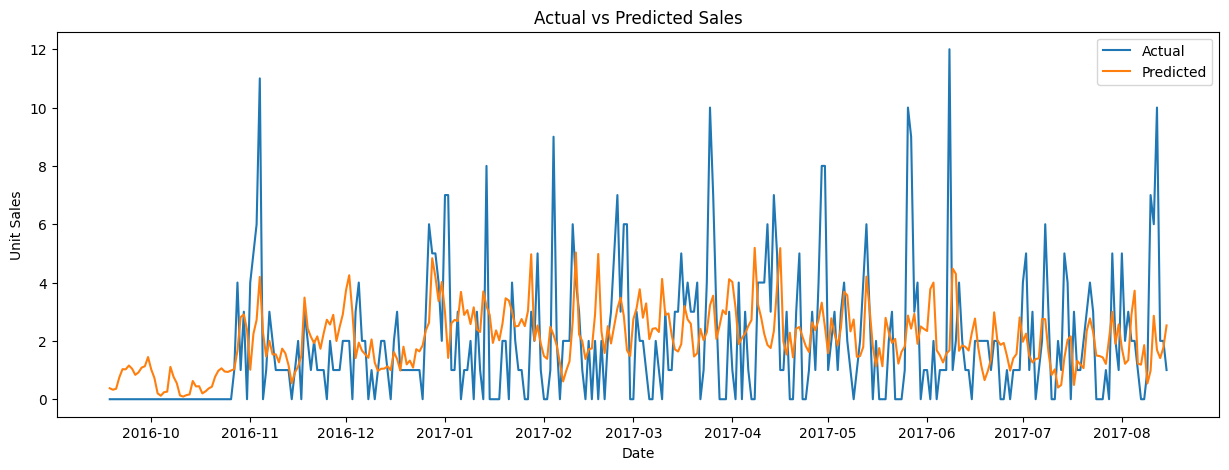

In [55]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    y_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

In [56]:
from lightgbm import LGBMRegressor

In [57]:
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [58]:
lgb_pred = lgb_model.predict(X_test)

In [59]:
lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))

print("LightGBM MAE:", lgb_mae)
print("LightGBM RMSE:", lgb_rmse)

LightGBM MAE: 1.517198107868969
LightGBM RMSE: 2.1518828690361733


In [60]:
print("Random Forest")
print("MAE:", mae)
print("RMSE:", rmse)

print("\nLightGBM")
print("MAE:", lgb_mae)
print("RMSE:", lgb_rmse)

Random Forest
MAE: 1.551942771084337
RMSE: 2.1138360001528427

LightGBM
MAE: 1.517198107868969
RMSE: 2.1518828690361733


In [61]:
importance = pd.Series(
    lgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

rolling_30         1079
rolling_7           864
rolling_14          758
day_of_month        600
lag_1               596
lag_14              504
lag_7               452
month               414
day_of_week_num     401
year                196
dtype: int32

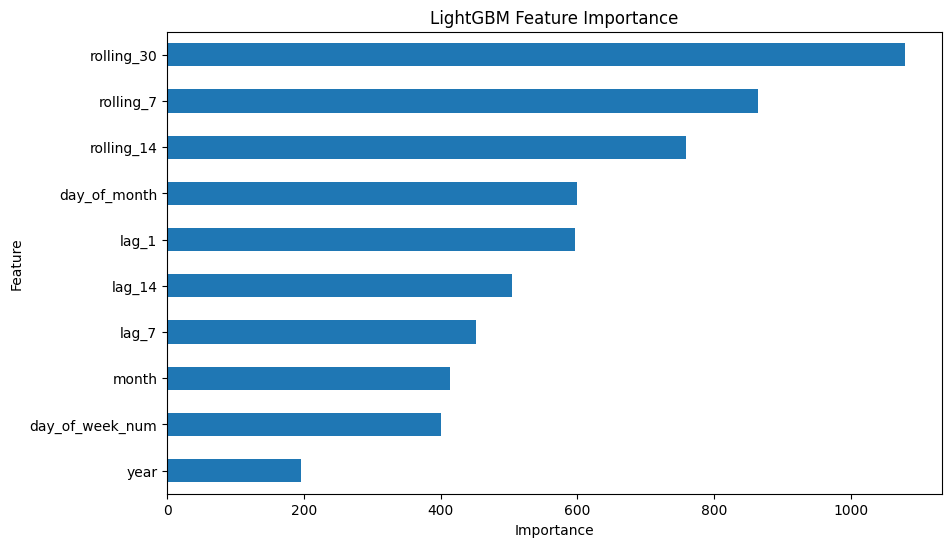

In [62]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind="barh")

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [63]:
import mlflow

In [64]:
mlflow.set_experiment("demand_forecasting")

2026/10/05 01:31:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/05 01:31:11 INFO mlflow.store.db.utils: Updating database tables
2026/10/05 01:31:14 INFO mlflow.tracking.fluent: Experiment with name 'demand_forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:D:/demand-forecasting-inventory/notebooks/mlruns/1', creation_time=1791144074832, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791144074832, lifecycle_stage='active', name='demand_forecasting', tags={}, trace_location=None, workspace='default'>

In [65]:
with mlflow.start_run(run_name="random_forest_baseline"):

    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)

In [66]:
with mlflow.start_run(run_name="lightgbm_baseline"):

    mlflow.log_param("model", "LGBMRegressor")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("num_leaves", 31)

    mlflow.log_metric("MAE", lgb_mae)
    mlflow.log_metric("RMSE", lgb_rmse)

In [67]:
from lightgbm import LGBMRegressor

tuned_lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

tuned_lgb_model.fit(X_train, y_train)

tuned_pred = tuned_lgb_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))

print("Tuned LightGBM MAE:", tuned_mae)
print("Tuned LightGBM RMSE:", tuned_rmse)

Tuned LightGBM MAE: 1.5964497988428903
Tuned LightGBM RMSE: 2.22783101466239


In [68]:
naive_pred = test_data["lag_7"]

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print("Naive Baseline MAE:", naive_mae)
print("Naive Baseline RMSE:", naive_rmse)

Naive Baseline MAE: 2.0210843373493974
Naive Baseline RMSE: 2.958039891549808


In [69]:
with mlflow.start_run(run_name="lightgbm_tuned"):
    mlflow.log_param("model", "LGBMRegressor")
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("learning_rate", 0.03)
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("num_leaves", 50)
    mlflow.log_param("min_child_samples", 20)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    mlflow.log_metric("MAE", tuned_mae)
    mlflow.log_metric("RMSE", tuned_rmse)

In [70]:
import numpy as np

daily_demand_mean = train_data["unit_sales"].mean()
daily_demand_std = train_data["unit_sales"].std()

lead_time_days = 7
service_level_z = 1.65

safety_stock = service_level_z * daily_demand_std * np.sqrt(lead_time_days)

reorder_point = (
    daily_demand_mean * lead_time_days
    + safety_stock
)

print("Average Daily Demand:", daily_demand_mean)
print("Demand Standard Deviation:", daily_demand_std)
print("Lead Time (days):", lead_time_days)
print("Safety Stock:", safety_stock)
print("Reorder Point:", reorder_point)

Average Daily Demand: 2.412518853695324
Demand Standard Deviation: 3.0050714601780015
Lead Time (days): 7
Safety Stock: 13.118608396754407
Reorder Point: 30.006240372621676


In [71]:
forecasted_daily_demand = lgb_pred.mean()

lead_time_demand = forecasted_daily_demand * lead_time_days

forecast_safety_stock = service_level_z * daily_demand_std * np.sqrt(lead_time_days)

forecast_reorder_point = lead_time_demand + forecast_safety_stock

print("Average Forecasted Daily Demand:", forecasted_daily_demand)
print("Forecasted Lead-Time Demand:", lead_time_demand)
print("Safety Stock:", forecast_safety_stock)
print("Forecast-Based Reorder Point:", forecast_reorder_point)

Average Forecasted Daily Demand: 1.663687144395018
Forecasted Lead-Time Demand: 11.645810010765127
Safety Stock: 13.118608396754407
Forecast-Based Reorder Point: 24.764418407519535


In [72]:
order_horizon_days = 14

order_up_to_level = (
    forecasted_daily_demand * order_horizon_days
    + forecast_safety_stock
)

print("Order-Up-To Level:", order_up_to_level)

Order-Up-To Level: 36.41022841828466


In [73]:
def inventory_recommendation(current_inventory):
    if current_inventory <= forecast_reorder_point:
        order_quantity = max(
            0,
            order_up_to_level - current_inventory
        )
        
        return {
            "current_inventory": current_inventory,
            "reorder_point": forecast_reorder_point,
            "recommended_order_quantity": order_quantity,
            "action": "REORDER"
        }
    
    return {
        "current_inventory": current_inventory,
        "reorder_point": forecast_reorder_point,
        "recommended_order_quantity": 0,
        "action": "NO REORDER"
    }

In [74]:
print(inventory_recommendation(20))
print(inventory_recommendation(30))

{'current_inventory': 20, 'reorder_point': np.float64(24.764418407519535), 'recommended_order_quantity': np.float64(16.41022841828466), 'action': 'REORDER'}
{'current_inventory': 30, 'reorder_point': np.float64(24.764418407519535), 'recommended_order_quantity': 0, 'action': 'NO REORDER'}


In [75]:
inventory_levels = [10, 15, 20, 25, 30, 35, 40]

inventory_results = pd.DataFrame(
    [inventory_recommendation(level) for level in inventory_levels]
)

inventory_results["recommended_order_quantity"] = (
    np.ceil(inventory_results["recommended_order_quantity"])
)

inventory_results

,current_inventory,reorder_point,recommended_order_quantity,action
0,10,24.764418,27.0,REORDER
1,15,24.764418,22.0,REORDER
2,20,24.764418,17.0,REORDER
3,25,24.764418,0.0,NO REORDER
4,30,24.764418,0.0,NO REORDER
5,35,24.764418,0.0,NO REORDER
6,40,24.764418,0.0,NO REORDER


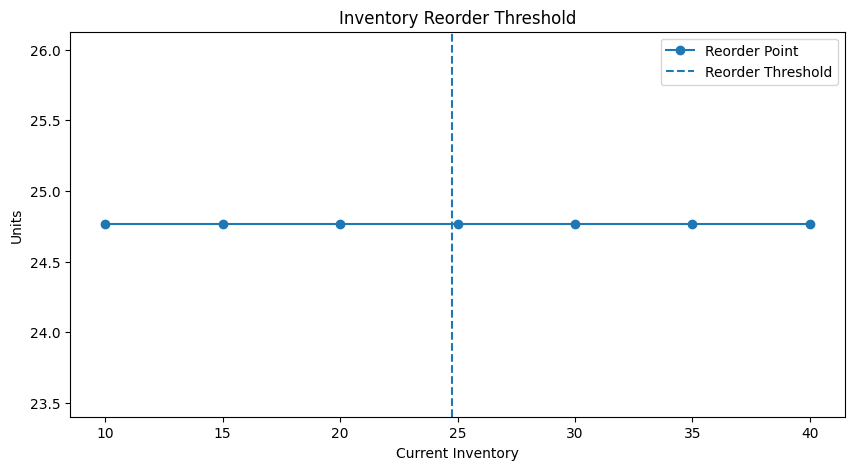

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    inventory_results["current_inventory"],
    inventory_results["reorder_point"],
    marker="o",
    label="Reorder Point"
)

plt.axvline(
    forecast_reorder_point,
    linestyle="--",
    label="Reorder Threshold"
)

plt.xlabel("Current Inventory")
plt.ylabel("Units")
plt.title("Inventory Reorder Threshold")
plt.legend()
plt.show()

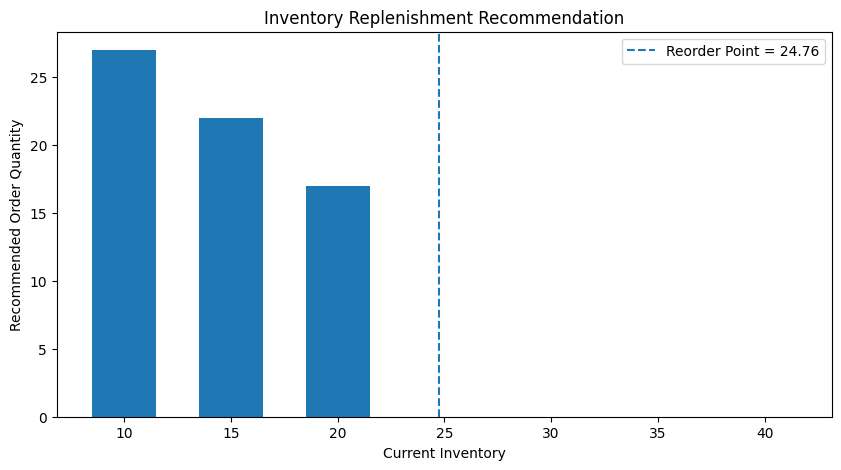

In [77]:
plt.figure(figsize=(10, 5))

plt.bar(
    inventory_results["current_inventory"],
    inventory_results["recommended_order_quantity"],
    width=3
)

plt.axvline(
    forecast_reorder_point,
    linestyle="--",
    label=f"Reorder Point = {forecast_reorder_point:.2f}"
)

plt.xlabel("Current Inventory")
plt.ylabel("Recommended Order Quantity")
plt.title("Inventory Replenishment Recommendation")
plt.legend()
plt.show()

In [78]:
import joblib

joblib.dump(lgb_model, "../lgb_demand_forecasting_model.pkl")

print("Best LightGBM model saved successfully.")

Best LightGBM model saved successfully.


In [79]:
import mlflow
import mlflow.lightgbm

with mlflow.start_run(run_name="lightgbm_best_model"):
    mlflow.log_param("model", "LGBMRegressor")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("num_leaves", 31)

    mlflow.log_metric("MAE", lgb_mae)
    mlflow.log_metric("RMSE", lgb_rmse)

    mlflow.lightgbm.log_model(
        lgb_model,
        name="lightgbm_model"
    )

print("Best LightGBM model logged to MLflow.")

Best LightGBM model logged to MLflow.


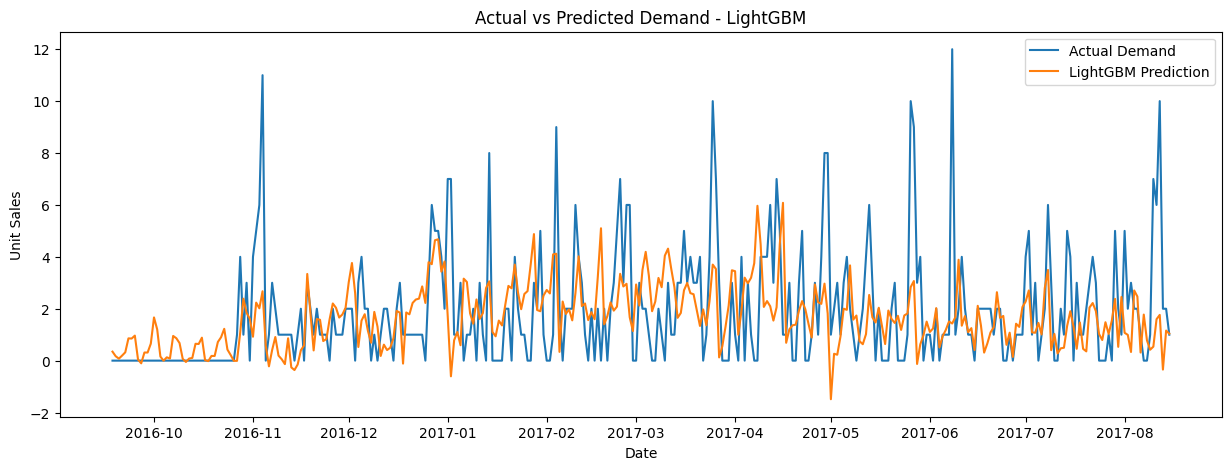

In [80]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Actual Demand"
)

plt.plot(
    y_test.index,
    lgb_pred,
    label="LightGBM Prediction"
)

plt.title("Actual vs Predicted Demand - LightGBM")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()